# Detecting the Trough of a Drawdown: A Volatility-Scaled Filter (RSTD)

**The problem.** Given a price series observed up to today, decide whether today is at or
near the bottom of a drawdown. This is an entry-timing question: not "will the market go
up" but "has the decline finished". Two rolling-window filters are constructed below as
candidate answers, both conditioning on the index trading below its own moving average
while its recent dispersion satisfies some condition.

**Why the problem is harder than it looks.** A trough is defined by what comes *after*
it: $t^\star$ is a local minimum only if the series rises for some interval following
$t^\star$. Any real-time rule is therefore estimating a quantity that is not observable
at the time the decision is made, and the target label itself depends on an arbitrary
choice of window. This is the central difficulty of the exercise and it shapes how the
filters have to be evaluated: a rule that identifies troughs beautifully in hindsight
has demonstrated nothing, because the hindsight label used the future.

Neither filter is evaluated in this notebook. See *Evaluation* at the end for the design
that would settle whether either carries information, and why the obvious evaluation is
the wrong one.

## Where this sits in the literature

The filters combine two heavily studied primitives, and the target sits inside a third
literature. Knowing all three is useful rather than discouraging: it supplies the named
benchmarks a new rule has to beat in order to be interesting.

**Primitive 1: price relative to a moving average.** A rule conditioned on
$X_t \lessgtr \bar{X}_{t-n:t}$ is a moving-average trend rule, among the oldest technical
rules studied formally. Its modern academic framing is time-series momentum (Moskowitz,
Ooi and Pedersen, *Journal of Financial Economics*, 2012), and Zakamulin and Giner
(*Quantitative Finance*, 2020) work out the precise relationship between momentum rules
and moving-average rules, which turn out to be different weightings of the same
underlying quantity rather than distinct ideas. The documented sign is *positive*: price
above its moving average tends to precede positive returns. These filters condition on
price being **below** its moving average, taking the contrarian side of a well-documented
relationship. That is a choice needing a defence, not a neutral starting point.

**Primitive 2: a quantity measured in units of its own rolling standard deviation.** A
band of the form $\bar{x}_t \pm k\hat{\sigma}_t$ on a rolling window is a Bollinger Band,
and mean-reversion rules built on band crossings are among the most widely backtested
rules in existence. Variant 1 below differs from the textbook construction in one
specific way worth stating: Bollinger applies both the mean and the band to *price*,
whereas variant 1 applies the mean to price and the band to *returns*. Its band component
is therefore closer to a standardised return shock, $z_t = r_t/\hat{\sigma}_t$, than to a
Bollinger band proper.

**The target: turning-point detection.** Dating peaks and troughs in a series is its own
field. The classical reference algorithm is Bry-Boschan, which locates turning points
subject to minimum phase-length and amplitude constraints, and it is explicitly a
*retrospective* procedure. The real-time versions are regime-switching models in the
Hamilton (1989) tradition, which estimate a filtered probability of being in the low
state given information up to $t$, and sequential change-point detectors of the CUSUM
family. What these share, and what a threshold rule lacks, is an explicit treatment of
the fact that the state is latent: they return a probability rather than a flag, and
that probability is revised as evidence arrives. A filter that returns a hard boolean is
making a much stronger claim on much less machinery.

**The economics that would have to be true.** For a contrarian entry rule to work at
short horizons, short-term reversal has to be present: Jegadeesh (*Journal of Finance*,
1990) and Lehmann (*Quarterly Journal of Economics*, 1990) document exactly this at
weekly and monthly frequencies. There is also a directly opposing result to contend
with. Moreira and Muir (*Journal of Finance*, 2017) find that *reducing* exposure when
recent realised volatility is high raises Sharpe ratios, which is close to the opposite
of buying into a high-dispersion drawdown. Any positive result here has to explain itself
against that finding, not only against buy-and-hold.

**And one more benchmark, the one most likely to win.** For an entry-timing rule on an
index with positive drift, the benchmark to beat is not "a random day". It is *buying
immediately*. Waiting for a signal means holding cash, and on a series that drifts upward
the cost of waiting compounds. A rule can identify troughs better than chance and still
lose to lump-sum entry. The evaluation below is written to measure both things
separately, because they are different claims.

**What these filters would contribute, if anything.** Not either primitive. It would have
to be the *interaction*: price below trend **and** a dispersion condition, jointly
isolating a regime that neither component isolates alone. Whether that interaction
carries information beyond its two parts is an empirical question, and it is the
question the evaluation section is built to answer.

## Setup

In [1]:
from __future__ import annotations

import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Walk up to the repository root (the directory containing `src/`) so this
# notebook imports the same way regardless of how deeply it is nested.
REPO_ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
                 if (p / "src").is_dir())
sys.path.append(str(REPO_ROOT))

from src.data import load_prices, levered_series

In [2]:
# --- Configuration -----------------------------------------------------------
TICKER = "^SPX"
TRADING_DAYS = 252

# --- Plot styling ------------------------------------------------------------
# Categorical slots 1-2 of the repository palette, matching src/plotting.py.
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, MUTED = "#0b0b0b", "#52514e"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "grid.color": "#e6e5e1",
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "font.size": 10,
})

## Data

`load_prices` caches to `data/` on first use, so this notebook re-executes
deterministically and without a network connection once it has been run once.

In [3]:
prices = load_prices(TICKER, period="max", interval="1d")
print(f"{TICKER}: {len(prices):,} daily closes, "
      f"{prices.index[0]:%Y-%m-%d} to {prices.index[-1]:%Y-%m-%d}")

^SPX: 24,791 daily closes, 1927-12-30 to 2026-09-11


## Variant 1: RSTD

Let $X_t$ be the index level (or a levered proxy of it, below) and $r_t = X_t/X_{t-1} - 1$
its daily simple return. Over a rolling window of $n$ trading days define

$$\hat{\mu}_t = \frac{1}{n}\sum_{i=0}^{n-1} X_{t-i}, \qquad
\hat{\sigma}_t = \operatorname{sd}\!\left(r_{t-n+1}, \dots, r_t\right).$$

The filter is the conjunction of a trend condition and a volatility-band condition:

$$\text{RSTD}_t \;=\; \mathbb{1}\!\left\{X_t < \hat{\mu}_t\right\}
\;\cdot\;
\begin{cases}
\mathbb{1}\!\left\{r_t > -k\hat{\sigma}_t\right\} & \texttt{direction="above"} \\[4pt]
\mathbb{1}\!\left\{r_t < -k\hat{\sigma}_t\right\} & \texttt{direction="below"}
\end{cases}$$

Note that $\hat{\mu}_t$ is a rolling mean of the **level** while $\hat{\sigma}_t$ is a
rolling standard deviation of **returns**. The two conditions therefore live on
different scales by construction, which is fine because each is compared only against a
quantity of its own kind, but it is the reason this is not a Bollinger band.

### On the levered series

Setting `leverage` to $L \neq 1$ builds a daily-rebalanced proxy
$\prod_{s \le t}(1 + L r_s)$ rather than rescaling the filter. This changes the filter's
behaviour rather than merely its axis, because volatility drag makes the levered series
fall below its own moving average more often and for longer. It is a gross-of-cost
proxy: it captures the drag but not financing costs or an expense ratio, so a real
levered product performs strictly worse than this series.

In [4]:
def rstd_signal(
    prices: pd.Series,
    roll: int = TRADING_DAYS,
    k: float = 3.0,
    leverage: float = 1.0,
    direction: str = "above",
) -> pd.DataFrame:
    """Rolling volatility-band filter conditioned on a moving-average trend.

    Parameters
    ----------
    prices
        Daily close price series.
    roll
        Rolling window length in trading days, used for both the level mean and
        the return standard deviation.
    k
        Band width in rolling standard deviations. The band sits at ``-k * sigma``.
    leverage
        Daily-rebalanced leverage applied before the filter is computed. ``1.0``
        leaves the series as a normalised price index.
    direction
        ``"above"`` fires when the return is inside the lower band (the original
        2023 formulation); ``"below"`` fires when it breaches the band.

    Returns
    -------
    pandas.DataFrame
        Columns ``level``, ``ret``, ``mu``, ``sigma``, ``band``, ``below_trend``,
        ``shock`` and ``signal``, indexed by date, with the rolling burn-in
        removed.
    """
    if direction not in {"above", "below"}:
        raise ValueError(f"direction must be 'above' or 'below', got {direction!r}")

    level = levered_series(prices, leverage)
    ret = level.pct_change()
    mu = level.rolling(roll).mean()
    sigma = ret.rolling(roll).std()
    band = -k * sigma

    below_trend = level < mu
    shock = ret > band if direction == "above" else ret < band

    frame = pd.DataFrame({
        "level": level, "ret": ret, "mu": mu, "sigma": sigma, "band": band,
        "below_trend": below_trend, "shock": shock,
    }).dropna()
    frame["signal"] = frame["below_trend"] & frame["shock"]
    return frame

In [5]:
def plot_signal(
    frame: pd.DataFrame,
    title: str,
    color: str = BLUE,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    """Plot the log level with the filter's active days shaded."""
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 4.4))

    log_level = np.log(frame["level"] / frame["level"].iloc[0])
    ax.fill_between(
        frame.index, 0, 1, where=frame["signal"].to_numpy(),
        transform=ax.get_xaxis_transform(),
        color=color, alpha=0.18, linewidth=0, label="filter active",
    )
    ax.plot(frame.index, log_level, color=INK, lw=1.3, label="log level (base 0)")
    ax.plot(frame.index, np.log(frame["mu"] / frame["level"].iloc[0]),
            color=ORANGE, lw=1.3, label="rolling mean")

    active = float(frame["signal"].mean())
    ax.set_title(f"{title}  -  active on {active:.1%} of days", loc="left")
    ax.set_ylabel("log level")
    ax.grid(axis="y", alpha=0.7)
    ax.set_axisbelow(True)
    ax.legend(loc="upper left", ncols=3)
    return ax

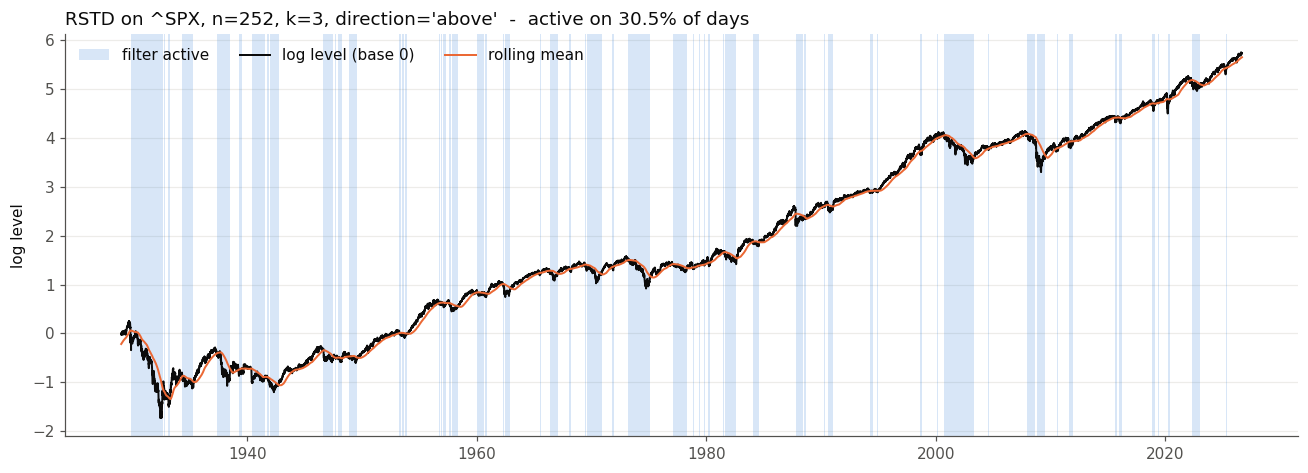

below_trend   30.9%
shock         99.1%
signal        30.5%


In [26]:
rstd = rstd_signal(prices, roll=TRADING_DAYS, k=3.0, leverage=1.0, direction="above")
plot_signal(rstd, f"RSTD on {TICKER}, n=252, k=3, direction='above'")
plt.tight_layout()
plt.show()

print(rstd[["below_trend", "shock", "signal"]].mean().to_string(
    float_format=lambda v: f"{v:.1%}"))

**Reading the chart.** The shaded regions track the periods where the black line sits
under the orange one almost exactly. That is the finding to take from this first plot:
with `direction="above"` and $k=3$, the `shock` condition holds on the overwhelming
majority of days, because a return only fails to exceed $-3\hat{\sigma}_t$ on the rare
days of a genuine three-sigma decline. The printed frequencies confirm it.

So in the original formulation **the volatility band is doing almost no work**. The
filter is, to a close approximation, a pure below-the-moving-average condition with a
thin exclusion for crash days.

That said, as a trough detector this reading is not absurd. "Below trend, and no longer
falling hard" is a stabilisation heuristic: it waits for capitulation to stop rather than
trying to catch it. The problem is not the logic, it is that the band contributes so
little to the joint condition that the filter is effectively the trend component alone,
and the evaluation has to be designed to detect that.

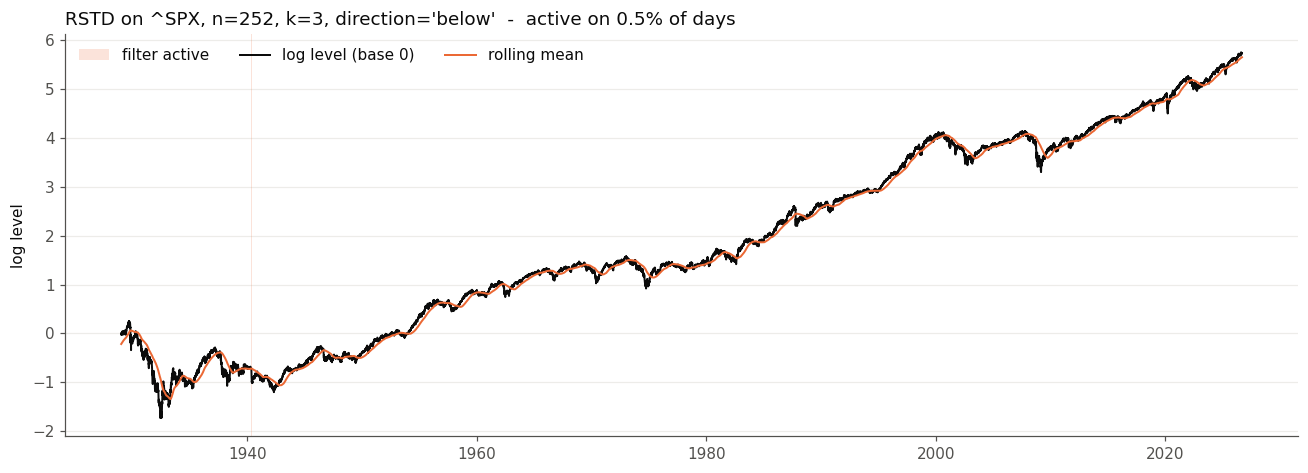

below_trend   30.9%
shock          0.9%
signal         0.5%


In [16]:
rstd_below = rstd_signal(prices, roll=TRADING_DAYS, k=3.0, leverage=1.0, direction="below")
plot_signal(rstd_below, f"RSTD on {TICKER}, n=252, k=3, direction='below'", color=ORANGE)
plt.tight_layout()
plt.show()

print(rstd_below[["below_trend", "shock", "signal"]].mean().to_string(
    float_format=lambda v: f"{v:.1%}"))

With `direction="below"` the filter fires only on days that are both below trend **and** a
three-sigma decline. This is the capitulation reading of the same idea: buy into the
worst days rather than waiting them out. It is the more natural reading of "find the
bottom of the dip", and it is what the exploratory plot in the 2023 original was set up
to look for.

The two readings encode genuinely different theories of where troughs sit, and they are
worth stating as such:

| `direction` | Theory of the trough | Failure mode |
|---|---|---|
| `"below"` | The bottom *is* the capitulation day; maximum dislocation marks the turn | Catching a falling knife; three-sigma days cluster, so the first one is rarely the last |
| `"above"` | The bottom is the first calm day after capitulation; the turn is marked by the *absence* of further shocks | Enters late, after part of the recovery; "calm" is not the same as "finished" |

The `"below"` variant also runs straight into a sample-size problem, which is the
standard tension in threshold rules: a threshold loose enough to give you data gives you
a condition that barely constrains anything, and a threshold tight enough to isolate a
regime leaves too few observations to say whether the regime matters. The $k$ sweep in
the evaluation section exists to make that trade-off visible, not to find the $k$ that
looks best.

## Variant 2: RMSTD

The second variant replaces the single-day return shock with a measure of how far the
level has drifted from its own mean, in relative terms, and compares that to the
dispersion of the same quantity:

$$M_t \;=\; \left(\frac{X_t - \hat{\mu}_t}{X_t}\right)^{\!2}, \qquad
\text{RMSTD}_t \;=\; \mathbb{1}\!\left\{X_t < \hat{\mu}_t\right\}\cdot\mathbb{1}\!\left\{M_t > B_t\right\}.$$

$M_t$ is a squared relative deviation, so it is non-negative and it responds to
*sustained* displacement from trend rather than to a single day's move. This makes it a
regime measure rather than an event measure, which is a genuinely different thing from
variant 1 and is the reason both are kept.

**The band $B_t$ has two definitions, and the choice matters.** The 2023 original used

$$B_t^{\text{raw}} \;=\; k \cdot \operatorname{sd}\!\left(M_{t-n+1}, \dots, M_t\right),$$

which compares a level against a standard deviation with no centre. Because $M_t$ is
strictly positive, a rolling standard deviation of it is not a location parameter, and
$k\hat{\sigma}(M)$ is not a threshold in any distributional sense: it is a scale
compared against a level. The conventional form of the same idea centres it first,

$$B_t^{\text{centred}} \;=\; \operatorname{mean}(M) + k \cdot \operatorname{sd}(M),$$

which is a $k$-sigma exceedance threshold and is what "$M$ is unusually large relative to
its recent history" normally means. Both are available below via `band_mode`, with
`"raw"` reproducing the original. They are not small variations on each other and should
not be assumed interchangeable.

**Burn-in.** $B_t$ is a rolling statistic of $M_t$, which is itself a rolling statistic,
so the series needs $2n$ observations before the first valid value rather than $n$.

In [8]:
def rmstd_signal(
    prices: pd.Series,
    roll: int = 5 * TRADING_DAYS,
    k: float = 4.0,
    leverage: float = 1.0,
    band_mode: str = "raw",
) -> pd.DataFrame:
    """Squared-relative-deviation regime filter.

    Parameters
    ----------
    prices
        Daily close price series.
    roll
        Rolling window length in trading days. Applied twice (to the level mean and
        then to the dispersion of ``M``), so the burn-in is ``2 * roll``.
    k
        Band width multiplier.
    leverage
        Daily-rebalanced leverage applied before the filter is computed.
    band_mode
        ``"raw"`` uses ``k * sd(M)`` (the original 2023 formulation); ``"centred"``
        uses ``mean(M) + k * sd(M)``, the conventional exceedance threshold.

    Returns
    -------
    pandas.DataFrame
        Columns ``level``, ``mu``, ``M``, ``band``, ``below_trend`` and ``signal``.
    """
    if band_mode not in {"raw", "centred"}:
        raise ValueError(f"band_mode must be 'raw' or 'centred', got {band_mode!r}")

    level = levered_series(prices, leverage)
    mu = level.rolling(roll).mean()
    M = ((level - mu) / level) ** 2

    if band_mode == "raw":
        band = k * M.rolling(roll).std()
    else:
        band = M.rolling(roll).mean() + k * M.rolling(roll).std()

    below_trend = level < mu
    frame = pd.DataFrame({
        "level": level, "mu": mu, "M": M, "band": band, "below_trend": below_trend,
    }).dropna()
    frame["signal"] = frame["below_trend"] & (frame["M"] > frame["band"])
    return frame

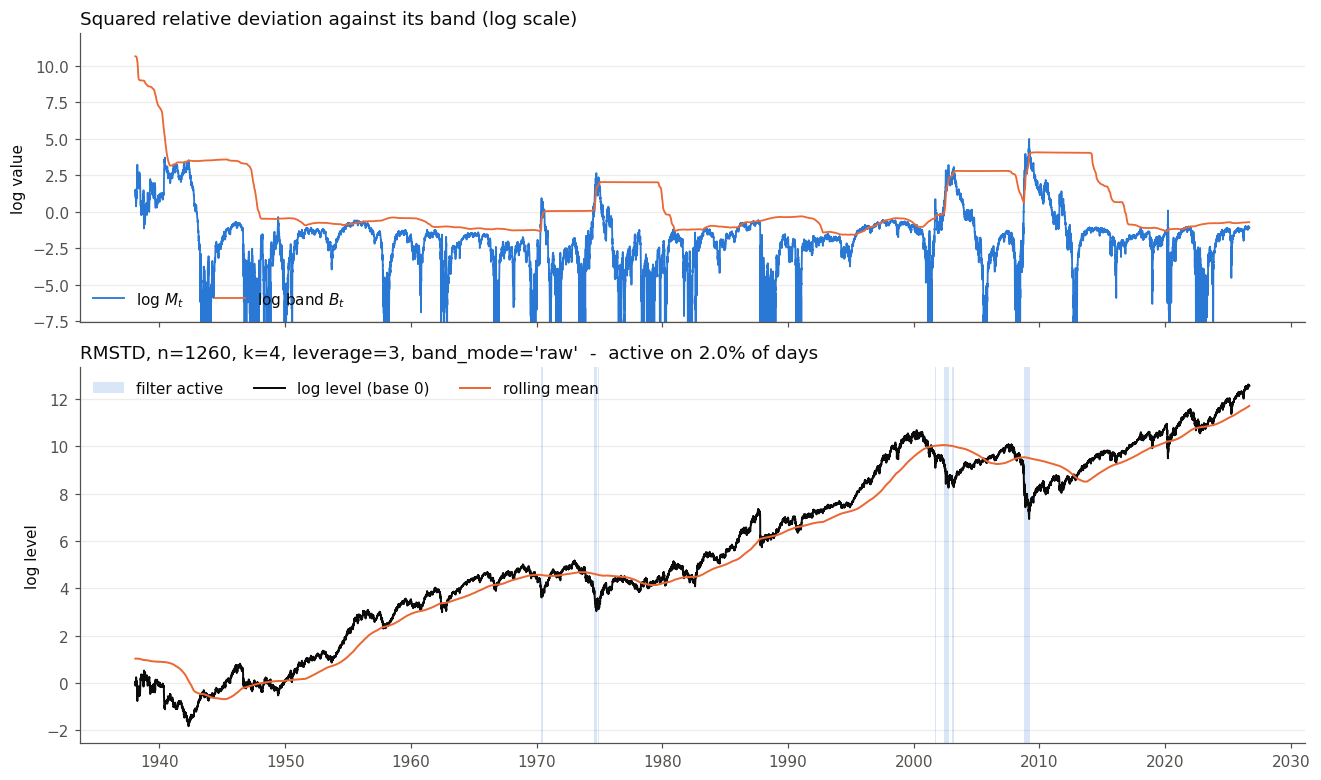

below_trend   29.3%
signal         2.0%


In [9]:
rmstd = rmstd_signal(prices, roll=5 * TRADING_DAYS, k=4.0, leverage=3.0, band_mode="raw")

fig, (ax_m, ax_p) = plt.subplots(2, 1, figsize=(12, 7.2), sharex=True,
                                 gridspec_kw={"height_ratios": [1, 1.3]})

ax_m.plot(rmstd.index, np.log(rmstd["M"]), color=BLUE, lw=1.2, label="log $M_t$")
ax_m.plot(rmstd.index, np.log(rmstd["band"]), color=ORANGE, lw=1.2, label="log band $B_t$")
ax_m.set_title("Squared relative deviation against its band (log scale)", loc="left")
ax_m.set_ylim(bottom=np.log(rmstd["band"].min()) - 6)  # clip the M -> 0 spikes at trend crossings
ax_m.set_ylabel("log value")
ax_m.grid(axis="y", alpha=0.7); ax_m.set_axisbelow(True)
ax_m.legend(loc="lower left", ncols=2)

plot_signal(rmstd, "RMSTD, n=1260, k=4, leverage=3, band_mode='raw'", ax=ax_p)

fig.tight_layout()
plt.show()

print(rmstd[["below_trend", "signal"]].mean().to_string(
    float_format=lambda v: f"{v:.1%}"))

**Reading the chart.** The top panel plots $M_t$ against its band on a log scale, which
is necessary because $M_t$ spans several orders of magnitude between quiet periods and
dislocations. The crossings in the top panel are what produce the shading in the bottom
panel, subject to the below-trend condition also holding.

The five-year window makes this a slow measure by design: it responds to multi-year
displacement from trend rather than to individual drawdowns, and combined with the $2n$
burn-in it discards the first ten years of the sample. That is a large price to pay in
observations, and it is a reason to check the result's sensitivity to `roll` rather than
treating 1260 days as given.

In [10]:
rmstd_centred = rmstd_signal(prices, roll=5 * TRADING_DAYS, k=4.0, leverage=3.0,
                             band_mode="centred")

comparison = pd.DataFrame({
    "raw: k * sd(M)": rmstd[["below_trend", "signal"]].mean(),
    "centred: mean(M) + k * sd(M)": rmstd_centred[["below_trend", "signal"]].mean(),
})
comparison.map("{:.1%}".format)

,raw: k * sd(M),centred: mean(M) + k * sd(M)
below_trend,29.3%,29.3%
signal,2.0%,1.6%


## Evaluation

**Nothing above constitutes evidence.** Both variants produce plots in which shaded
regions appear near local lows, and that appearance is not informative: *any* filter
conditioned on price being below its moving average will shade regions near local lows,
including one with no predictive content whatsoever. The visual is the thing most likely
to mislead here, precisely because it is persuasive.

The evaluation below is written specifically for a trough-detection rule, which is a
different target from a return-prediction rule and needs different metrics. It is not yet
implemented.

**1. Define the label, and define it retrospectively and explicitly.** Mark day $t$ as a
trough if $X_t = \min(X_{t-w}, \dots, X_{t+w})$ for a window $w$, and state $w$. Report
every downstream result for at least three values of $w$, because the label is an
arbitrary choice and any result that survives only one $w$ is an artefact of it.

**2. Score detection directly, not by proxy.** Forward return is a proxy for trough
proximity and a poor one. Score the filter on what it claims to do:

- **Distance to the nearest true trough**, in trading days, for each signal day. Report
  the distribution, not the mean: a rule that is usually 3 days early and occasionally
  400 days early is a different object from one that is consistently 20 days early.
- **Remaining drawdown after the signal**, $\min(X_{t..t+h})/X_t - 1$. This is the
  quantity a trough detector is actually trying to make small, and it is the number that
  punishes catching a falling knife.
- **Precision and recall against the labelled troughs**, with the base rate stated. A
  filter active on 40% of days will contain most troughs by construction, so recall
  without the base rate beside it means nothing.

**3. Benchmark against the alternatives that actually compete.** In order of how likely
they are to win:

- **Buy immediately.** On a drifting series this is the benchmark that usually beats
  timing rules, and it must be reported even when it wins.
- **The filter's own components alone.** `below_trend` with the band removed, and the
  band with the trend removed. If the joint condition beats neither, the interaction
  contributes nothing and the honest conclusion is that this is a moving-average rule.
- **A random-day baseline** matched on the number of entries.
- Optionally, **a Hamilton-style two-state regime-switching model** fitted to the return
  series, as the literature's real-time answer to the same question.

**4. Inference that accounts for overlap and clustering.** Forward returns at $h > 1$
overlap, and signal days arrive in clusters rather than independently, so the effective
sample size is far below the nominal one and a naive $t$-statistic is badly oversized. A
stationary block bootstrap with block length exceeding $h$ gives a $p$-value that
survives contact with the problem.

**5. Parameter sensitivity, reported in full.** Sweep $n$, $k$, `direction`, `band_mode`
and `leverage`, and report the whole surface rather than the best cell. A few dozen
combinations will produce something significant at the 5% level by construction; the
surface makes that visible and a single reported number hides it. A real result is a
contiguous region of the surface, not a spike.

**6. Out-of-sample separation.** Choose parameters on data up to a fixed date, then
evaluate once on everything after it. Once.

**7. Look-ahead, costs, and implementability.** Every rolling window must use only
information available at $t$; check this explicitly rather than assuming `rolling`
handles it. Then apply transaction costs, and for the levered variants financing costs,
which the `levered_series` proxy omits entirely.

## Limitations of the construction itself

**The target is latent and the filters do not treat it as such.** Both variants return a
hard boolean, while the state they are trying to detect is unobservable at decision time.
A probabilistic output, revised as evidence arrives, is the better-posed version of the
same idea and is what the regime-switching literature provides.

**Three-sigma days cluster.** Volatility clustering means the first three-sigma decline
of a drawdown is very often not the last. A capitulation rule with no persistence
requirement, and no concept of how many shocks have already occurred, will fire early and
repeatedly in exactly the episodes it most needs to get right.

**A single underlying is a single observation.** Every result here is one path of the
S&P 500, and a rule tuned on one series and tested on the same series has an in-sample
problem no statistical correction fixes. Running the filters unchanged across other
indices and asset classes is the cheapest available robustness check.

**The window lengths are inherited, not chosen.** 252 and 1260 days are round numbers, as
were the $k$ values.

**Regime dependence.** The sample spans several distinct volatility regimes, and a filter
calibrated on the full history is implicitly averaging over them. A regime-conditional
evaluation would be more informative than a full-sample one.